In [1]:
import numpy as np 				# math functions
import scipy					# scientific functions
import matplotlib.pyplot as plt 			# for plotting figures and setting their properties
import pandas as pd 				# handling data structures (loaded from files)
from scipy.stats import linregress 		# contains linregress (for linear regression)
from scipy.optimize import curve_fit as cfit 	# non-linear curve fitting
from sklearn.metrics import r2_score 		# import function that calculates R^2 score
from prettytable import PrettyTable 		# display data in visually table format
import scipy.ndimage as ndimage   		# import Multidimensional Image processing package
from scipy.signal import find_peaks        	             # for find local peaks in a signal
import math

d = 1/500 # mm/lines

df = pd.read_csv('Spectro_data.csv')
color = df['colour'].tolist()
angle = df['Grating Angle (deg)'].tolist()

wavelength = [d * math.sin(math.radians(a)) for a in angle]

Lines = {}

for n in range(0, len(angle)):
    key = f'Line %d' % (n + 1)
    value = [color[n], angle[n], wavelength[n]]
    Lines.update({key: value})

table = PrettyTable(["Grating Angle [deg]","Grating Wavelength [nm]","colour"])

for a, c, w in zip(angle, color, wavelength):
    table.add_row([a, w, c])

print(table)

prism_angle_vector = [1, 2, '', 4, 5, 6 , '', 8, 9]

table.add_column("Prism Angle [deg]", prism_angle_vector)

print(table)

+---------------------+-------------------------+--------+
| Grating Angle [deg] | Grating Wavelength [nm] | colour |
+---------------------+-------------------------+--------+
|        21.06        |  0.0007186907920117814  |  red   |
|        19.485       |  0.0006671201296638546  |  red   |
|        17.01        |   0.000585077213870508  | yellow |
|        14.58        |  0.0005034630973369942  | green  |
|        14.535       |  0.0005019427300823382  | green  |
|        14.265       |  0.0004928140572987028  |  blue  |
|        13.68        |  0.00047299799404744935 |  blue  |
|        12.96        |  0.0004485415218987624  | purple |
|        11.295       |  0.0003917211374481878  | purple |
+---------------------+-------------------------+--------+
+---------------------+-------------------------+--------+-------------------+
| Grating Angle [deg] | Grating Wavelength [nm] | colour | Prism Angle [deg] |
+---------------------+-------------------------+--------+-----------------

# Microwave

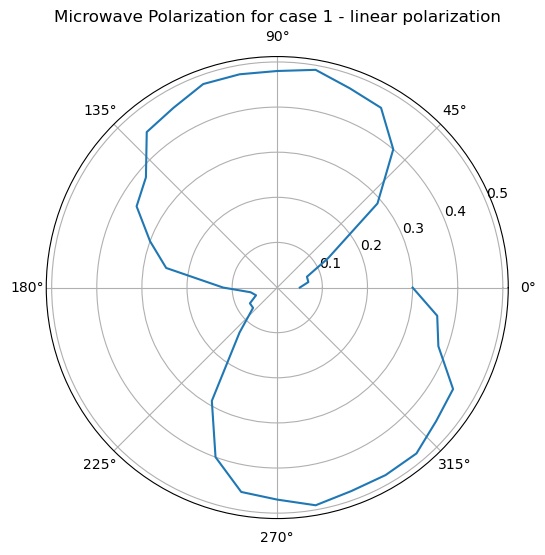

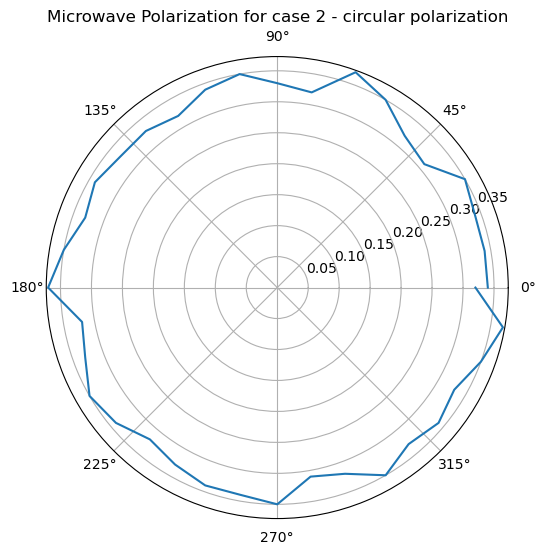

In [1]:
import numpy as np 				# math functions
import scipy					# scientific functions
import matplotlib.pyplot as plt 			# for plotting figures and setting their properties
import pandas as pd 				# handling data structures (loaded from files)
from scipy.stats import linregress 		# contains linregress (for linear regression)
from scipy.optimize import curve_fit as cfit 	# non-linear curve fitting
from sklearn.metrics import r2_score 		# import function that calculates R^2 score
from prettytable import PrettyTable 		# display data in visually table format
import scipy.ndimage as ndimage   		# import Multidimensional Image processing package
from scipy.signal import find_peaks        	             # for find local peaks in a signal
import math

df_mw = pd.read_csv("microwave_waveguide_data.csv")

# Again, assuming column names here based on typical lab setups
theta_deg = df_mw['theta(deg)'].values
Intensity1 = df_mw['power_1'].values
Intensity2 = df_mw['power_2'].values

# 2. Convert degrees to radians (plt.polar requires radians)
theta_rad = np.radians(theta_deg)

# 3. Plot the Polar Graph
plt.figure(figsize=(6, 6))
plt.polar(theta_rad, Intensity1)
plt.title("Microwave Polarization for case 1 - linear polarization")
plt.show()

plt.figure(figsize=(6, 6))
plt.polar(theta_rad, Intensity2)
plt.title("Microwave Polarization for case 2 - circular polarization")
plt.show()

# Acousto-Optic Effect

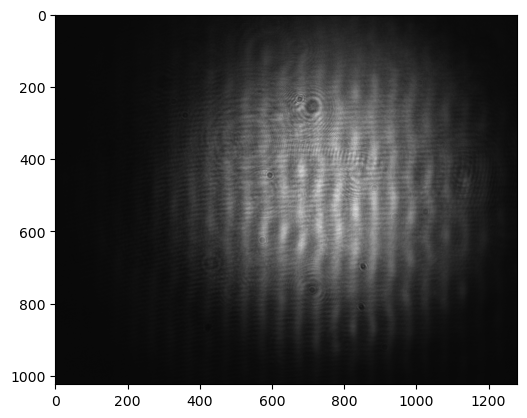

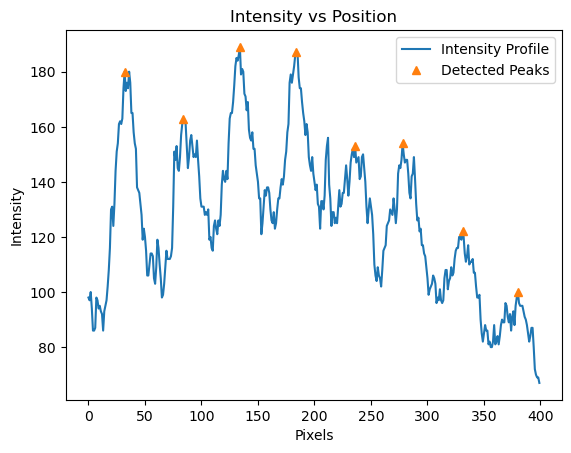

Speed of sound from near measurement: 537.45 m/s


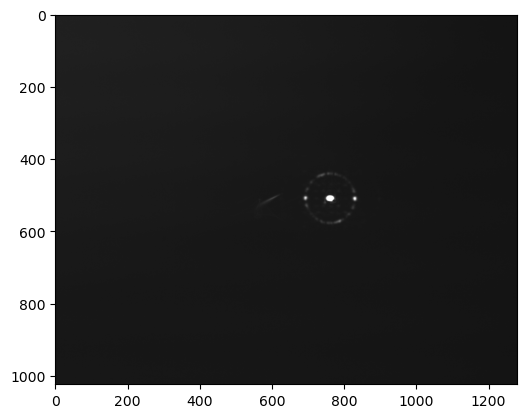

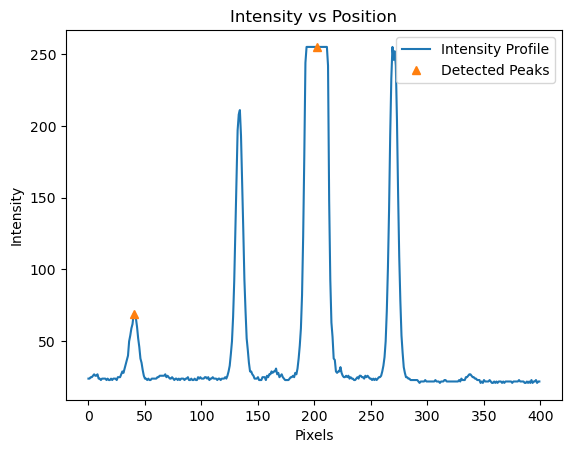

Speed of sound from far measurement: 468.52 m/s


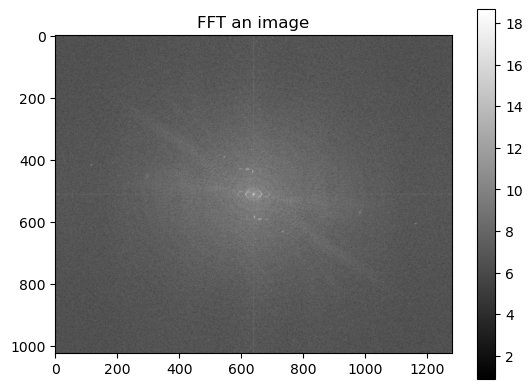

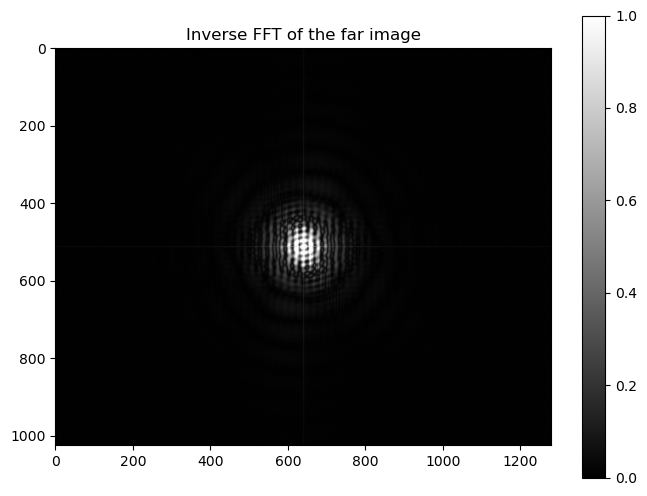

In [1]:
import scipy.ndimage as ndimage
from scipy.signal import find_peaks
import numpy as np 				# math functions
import scipy					# scientific functions
import matplotlib.pyplot as plt 			# for plotting figures and setting their properties
import pandas as pd 				# handling data structures (loaded from files)
from scipy.stats import linregress 		# contains linregress (for linear regression)
from scipy.optimize import curve_fit as cfit 	# non-linear curve fitting
from sklearn.metrics import r2_score 		# import function that calculates R^2 score
from prettytable import PrettyTable 		# display data in visually table format
import scipy.ndimage as ndimage   		# import Multidimensional Image processing package
from scipy.signal import find_peaks        	             # for find local peaks in a signal
import math

def calc_fft(image_path):

    image = plt.imread(image_path)

    # Convert to grayscale
    image = np.mean(image, axis=2)

    fft = np.fft.fft2(image)
    fft = np.fft.fftshift(fft)
    magnitude = np.abs(fft)

    magnitude = np.log1p(magnitude)

    # Display the result
    plt.figure()
    plt.imshow(magnitude, cmap='gray')
    plt.title('FFT an image')
    plt.colorbar()
    plt.show()


def calc_ifft(image_path):
    image = plt.imread(image_path)

    # Convert to grayscale
    if image.ndim == 3:
        image = np.mean(image, axis=2)

    center_y, center_x = image.shape[0] // 2, image.shape[1] // 2

    # FIXED: The actual coordinates of the central bright dot in the Far Field image
    peak_y = 510
    peak_x = 760

    shift_y = center_y - peak_y
    shift_x = center_x - peak_x

    # Roll the central peak to the geometric center
    fft_centered = np.roll(image, shift=(shift_y, shift_x), axis=(0, 1))

    # Shift zero-frequency component to the corners for the math
    fft_ready = np.fft.ifftshift(fft_centered)

    # Calculate Inverse FFT
    ifft = np.fft.ifft2(fft_ready)

    # Shift spatial center back to the middle
    ifft_shifted = np.fft.fftshift(ifft)
    magnitude = np.abs(ifft_shifted)

    # Normalize and clip
    p_lower, p_upper = np.percentile(magnitude, (0.1, 99.9))
    magnitude_clipped = np.clip(magnitude, p_lower, p_upper)
    magnitude_norm = (magnitude_clipped - p_lower) / (p_upper - p_lower + 1e-8)

    plt.figure(figsize=(8, 6))
    plt.imshow(magnitude_norm, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Inverse FFT of the far image')
    plt.colorbar()
    plt.show()

pixel_size = 5.2e-6
generator_frequency = 2.079e6
l = 632.8e-9
f3 = 0.3 # 300 mm = 0.3 meters

def process_field_img(path, dist, deg, p_0, promi):
    image = plt.imread(path)

    plt.imshow(image)

    rotated_image = ndimage.rotate(image, deg, reshape=True)

    plt.imshow(rotated_image)

    x = np.linspace(0, 399, 400)

    x_0, y_0 = p_0
    y = rotated_image[y_0, x_0 : x_0 + len(x), 0]

    peaks, _ = find_peaks(y, distance=dist, prominence=promi)

    # Create a new figure and plot the intensity slice
    plt.figure()
    plt.plot(y, label="Intensity Profile")

    # Plot triangles ('^') exactly at the peak coordinates
    plt.plot(peaks, y[peaks], '^', label="Detected Peaks")

    plt.title("Intensity vs Position")
    plt.xlabel("Pixels")
    plt.ylabel("Intensity")
    plt.legend()
    plt.show()

    return peaks

    peaks_difference = np.diff(peaks)
    avg_dist = np.mean(peaks_difference)

    delta_x = avg_dist * pixel_size

    speed_of_sound = generator_frequency * (f3 * l) / delta_x



near_peaks = process_field_img("NearField_2079MHz.tif", 40, 0, (600,600), 5)

peaks_difference = np.diff(near_peaks)
avg_dist = np.mean(peaks_difference)
delta_x = avg_dist * pixel_size
v_near = generator_frequency * delta_x
print(f"Speed of sound from near measurement: {v_near:.2f} m/s")



far_peaks = process_field_img("FarField_2079MHz.tif", 100, 0, (560, 510), 10)
peaks_difference = np.diff(far_peaks)
avg_dist = np.mean(peaks_difference)
delta_x = avg_dist * pixel_size
v_far = generator_frequency * (f3 * l) / delta_x
print(f"Speed of sound from far measurement: {v_far:.2f} m/s")

calc_fft(r'NearField_2079MHz.tif')
calc_ifft(r'FarField_2079MHz.tif')


# Amp_fit

Fitted [a, lam, phi]: [ 2.45426026  5.75434491 -2.54372269]
Parameter Errors: [0.05685658 0.03665711 0.10642713]
R^2 Score: 0.9011


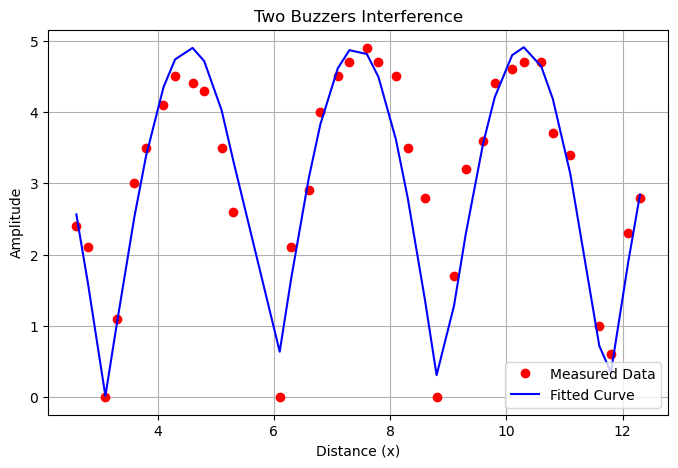

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit as cfit
from sklearn.metrics import r2_score

# 1. Load Data
df_buzz = pd.read_csv("2_buzzers_data.csv")
x_data = df_buzz['x_1 (cm)'].values # distance from buzzer
y_data = df_buzz['Amplitude'].values # measured amplitude

L = 1

def f(x, a, lam, phi):
    return np.abs(2 * a * np.cos((np.pi / lam) * (2 * x - L) + phi / 2))

p0 = [2.4, 6, -1.5]
params, cov = cfit(f, x_data, y_data, p0=p0)

y_pred = f(x_data, *params)
Rsq = r2_score(y_data, y_pred)

errors = np.sqrt(np.diag(cov))

print(f"Fitted [a, lam, phi]: {params}")
print(f"Parameter Errors: {errors}")
print(f"R^2 Score: {Rsq:.4f}")

# 6. Plotting
plt.figure(figsize=(8, 5))
plt.plot(x_data, y_data, 'ro', label='Measured Data')
plt.plot(x_data, y_pred, 'b-', label='Fitted Curve')
plt.xlabel('Distance (x)')
plt.ylabel('Amplitude')
plt.title('Two Buzzers Interference')
plt.legend()
plt.grid(True)
plt.show()